## Feature Extraction

In [ ]:
## feature extraction is mostly used in text and images. (image processing, NLP, Compputer vision, signal processing)
# we are gonna models like PCA, LDA, t-SNE...

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
## for PCA we gonna use load_wone dataset which is mutli class calssification
## and split into train test.

In [5]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
X, y = load_wine(return_X_y= True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.3,
    random_state=42,
    stratify= y
)

## PCA

In [ ]:
## PCA
# PCA(
#     n_components=None,           # Most important
#     copy=True,                   # Practical importance
#     whiten=False,                # Often useful
#     svd_solver='auto',           # Algorithm choice
#     tol=0.0,                     # Tolerance
#     iterated_power='auto',       # For randomized solver
#     n_oversamples=10,            # For randomized solver
#     power_iteration_normalizer='auto',  # For randomized solver
#     random_state=None            # Reproducibility
# )

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
## scale features first before using PCA

pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5, whiten= True)),
    ('model', LogisticRegression(max_iter=5000))
])
pipe_pca.fit(X_train, y_train)
y_pred = pipe_pca.predict(X_test)
print(accuracy_score(y_test, y_pred))
## instead we can use score on test_set
print(pipe_pca.score(X_test, y_test))

0.9814814814814815
0.9814814814814815


In [ ]:
print(pipe_pca.named_steps['pca'].components_)

[ 0.15763477 -0.25237011 -0.01662626 -0.23514225  0.14285062  0.38989121
  0.42596901 -0.28675917  0.30864294 -0.08886736  0.30119689  0.37783572
  0.28836287]


In [29]:
## we can check variance explain to choose best componenets
print(pipe_pca.named_steps['pca'].explained_variance_ratio_.sum())

0.9006668766038878


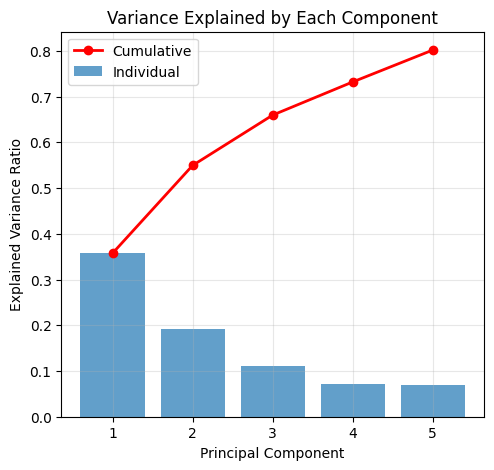

In [36]:
pca_obj = pipe_pca.named_steps['pca']

# Plot explained variance ratio
plt.figure(figsize=(12, 5))

# Subplot 1: Explained variance ratio
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca_obj.explained_variance_ratio_) + 1), 
        pca_obj.explained_variance_ratio_, 
        alpha=0.7, label='Individual')
plt.plot(range(1, len(pca_obj.explained_variance_ratio_) + 1), 
         np.cumsum(pca_obj.explained_variance_ratio_), 
         'ro-', linewidth=2, label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by Each Component')
plt.legend()
plt.grid(True, alpha=0.3)


## LDA

In [ ]:
# LDA(
#     solver='svd'('svd', 'lsqr','eigen'),           # Most important - algorithm choice
#     shrinkage=None,         # Regularization (critical for high dimensions)
#     priors=None,            # Class prior probabilities
#     n_components=None,      # Number of discriminants to keep
#     store_covariance=False, # Store covariance matrices
#     tol=0.0001,            # Tolerance for rank detection
#     covariance_estimator=None  # Custom covariance estimator
# )

In [39]:
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size= 0.3, random_state= 42, stratify=y)

In [42]:
pipe_lda = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components= 2))
])
pipe_lda.fit(X_train, y_train)
pipe_lda.score(X_test, y_test)

0.9777777777777777

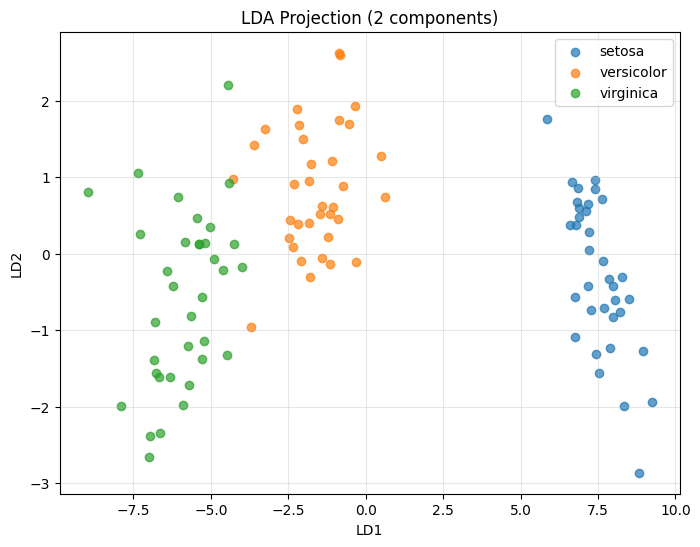

In [45]:
# Fit with 2 components
pipe_viz = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2, solver= 'svd'))
])
X_lda = pipe_viz.fit_transform(X_train, y_train)

# Scatter plot
plt.figure(figsize=(8,6))
for i, label in enumerate(iris.target_names):
    mask = y_train == i
    plt.scatter(X_lda[mask, 0], X_lda[mask, 1], label=label, alpha=0.7)
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('LDA Projection (2 components)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()